# Shor–McCarty: Full-Sample $p(t,x)$ and $b(t,x)$ Diagnostics

This notebook implements the two requested diagnostics:

1. **Plot $p(t,x)$ at different times.**
2. **Train on all available times and plot $b(t,x)$ at all times.**

The sample is the same balanced national lower-house Shor–McCarty density panel used in the previous notebook:

- **Years:** 1998–2020
- **Ideology coordinate:** Shor–McCarty `np_score`
- **Time step:** one calendar year

### Important change from the forecasting notebook

There is **no train/test split here**. All years from 1998 through 2020 are used to estimate the drift. Therefore the figures below are **full-sample model diagnostics**, not out-of-sample forecasts.

The previous linear model used a fixed drift $b(x)$. To make “plot $b$ at all times” meaningful, we now use a time-dependent drift:

$$
b = b_\phi(t,x).
$$


In [1]:
from pathlib import Path
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn

SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# Colab-friendly data loading
# ------------------------------------------------------------
DATA_FILE = Path("national_house_density_1998_2020.csv.gz")

if not DATA_FILE.exists():
    try:
        from google.colab import files
        print("Upload: national_house_density_1998_2020.csv.gz")
        uploaded = files.upload()
        candidates = [name for name in uploaded if name.endswith(".csv.gz")]
        if DATA_FILE.name in uploaded:
            DATA_FILE = Path(DATA_FILE.name)
        elif len(candidates) == 1:
            DATA_FILE = Path(candidates[0])
        else:
            raise FileNotFoundError("Upload exactly one .csv.gz file.")
    except ImportError:
        raise FileNotFoundError(
            "Put national_house_density_1998_2020.csv.gz in the same folder as this notebook."
        )

DENSITY_COLUMN = "density_legislator_weighted"

df = pd.read_csv(DATA_FILE)
years = np.sort(df["year"].unique()).astype(int)
x_grid = np.sort(df["x"].unique()).astype(float)

p_observed = (
    df.pivot(index="year", columns="x", values=DENSITY_COLUMN)
      .loc[years, x_grid]
      .to_numpy(float)
)

p_observed = np.maximum(p_observed, 0.0)
p_observed /= np.trapezoid(p_observed, x_grid, axis=1)[:, None]

# Physical time in years for derivatives.
t_year = (years - years[0]).astype(float)

# Normalized time only for the neural-network input.
t_norm = t_year / t_year[-1]

print(f"Years: {years[0]}–{years[-1]} ({len(years)} time points)")
print("p shape:", p_observed.shape)
print("x range:", (x_grid.min(), x_grid.max()))


Device: cpu
Years: 1998–2020 (23 time points)
p shape: (23, 401)
x range: (np.float64(-4.5), np.float64(5.0))


## 1. Plot $p(t,x)$ at different times

Here $p(t,x)$ is the observed annual KDE density of legislator ideology.

We first plot several widely separated years so the evolution of the distribution can be seen directly rather than only through a heatmap.


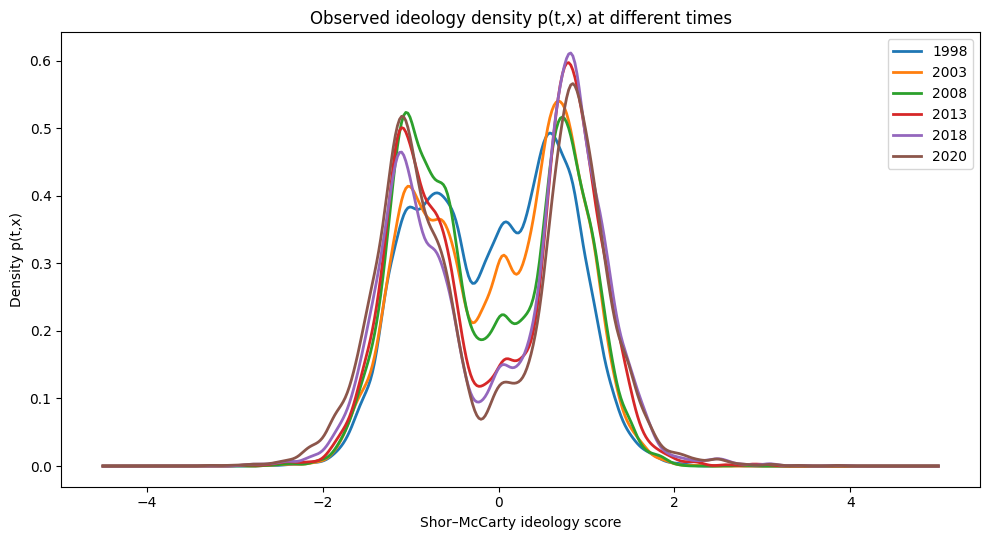

In [2]:
snapshot_years = [1998, 2003, 2008, 2013, 2018, 2020]

plt.figure(figsize=(10, 5.5))
for year in snapshot_years:
    idx = np.where(years == year)[0][0]
    plt.plot(x_grid, p_observed[idx], label=str(year), linewidth=2)

plt.xlabel("Shor–McCarty ideology score")
plt.ylabel("Density p(t,x)")
plt.title("Observed ideology density p(t,x) at different times")
plt.legend()
plt.tight_layout()
plt.show()


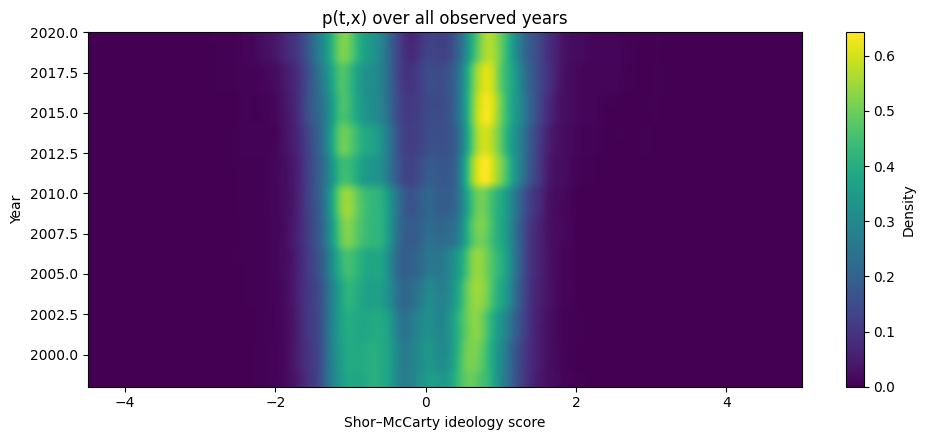

In [3]:
plt.figure(figsize=(10, 4.5))
plt.imshow(
    p_observed,
    aspect="auto",
    origin="lower",
    extent=[x_grid.min(), x_grid.max(), years.min(), years.max()],
)
plt.xlabel("Shor–McCarty ideology score")
plt.ylabel("Year")
plt.title("p(t,x) over all observed years")
plt.colorbar(label="Density")
plt.tight_layout()
plt.show()


## 2. Train the drift using all times

We now use every observed year from 1998 through 2020.

The Fokker–Planck equation is

$$
p_t + \partial_x\bigl(b_\phi(t,x)p\bigr) - Dp_{xx}=0.
$$

The key difference from the previous fixed-drift model is

$$
b_\phi=b_\phi(t,x),
$$

so the drift at the same ideological position can change over calendar time.

For this diagnostic, the observed KDE panel $p(t,x)$ is treated as fixed. We train a neural network for $b_\phi(t,x)$ so that the observed panel satisfies the Fokker–Planck equation as closely as possible.

Define the residual

$$
R(t,x)
=
p_t
+
\partial_x\left(b_\phi(t,x)p(t,x)\right)
-
Dp_{xx}.
$$

The main training loss is

$$
\mathcal{L}_{\mathrm{PDE}}
=
\frac{1}{N}
\sum_{t,x}
w(t,x)R(t,x)^2,
$$

where the weight $w(t,x)$ gives more importance to regions where the empirical density is non-negligible.

We also impose the no-flux boundary condition

$$
b_\phi(t,x)p(t,x)-Dp_x(t,x)=0
$$

at the left and right edges of the ideology grid.

For now, $D=0.01$ is kept fixed. This is the value selected in the earlier Shor–McCarty training-period validation; the purpose of this notebook is the professor-requested **full-time visualization of $p$ and $b$**, not a new diffusion-parameter selection exercise.


In [4]:
# ------------------------------------------------------------
# Prepare fixed empirical derivatives
# ------------------------------------------------------------
D = 0.01

# Mild smoothing is used only to stabilize numerical derivatives.
p_smooth = gaussian_filter(
    p_observed,
    sigma=(0.5, 1.0),
    mode="nearest",
)
p_smooth = np.maximum(p_smooth, 0.0)
p_smooth /= np.trapezoid(p_smooth, x_grid, axis=1)[:, None]

p_t = np.gradient(
    p_smooth,
    t_year,
    axis=0,
    edge_order=2,
)
p_x = np.gradient(
    p_smooth,
    x_grid,
    axis=1,
    edge_order=2,
)
p_xx = np.gradient(
    p_x,
    x_grid,
    axis=1,
    edge_order=2,
)

dx = float(x_grid[1] - x_grid[0])
dt_norm = float(t_norm[1] - t_norm[0])

P = torch.tensor(p_smooth, dtype=torch.float32, device=device)
PT = torch.tensor(p_t, dtype=torch.float32, device=device)
PX = torch.tensor(p_x, dtype=torch.float32, device=device)
PXX = torch.tensor(p_xx, dtype=torch.float32, device=device)

T_mesh, X_mesh = np.meshgrid(t_norm, x_grid, indexing="ij")

x_center = 0.5 * (x_grid.min() + x_grid.max())
x_scale = 0.5 * (x_grid.max() - x_grid.min())
X_scaled = (X_mesh - x_center) / x_scale

T_flat = torch.tensor(
    T_mesh.reshape(-1, 1),
    dtype=torch.float32,
    device=device,
)
X_flat = torch.tensor(
    X_scaled.reshape(-1, 1),
    dtype=torch.float32,
    device=device,
)


def diff_x(values, dx):
    out = torch.empty_like(values)
    out[:, 1:-1] = (values[:, 2:] - values[:, :-2]) / (2.0 * dx)
    out[:, 0] = (values[:, 1] - values[:, 0]) / dx
    out[:, -1] = (values[:, -1] - values[:, -2]) / dx
    return out


def diff_t(values, dt):
    out = torch.empty_like(values)
    out[1:-1] = (values[2:] - values[:-2]) / (2.0 * dt)
    out[0] = (values[1] - values[0]) / dt
    out[-1] = (values[-1] - values[-2]) / dt
    return out


class TimeDependentDrift(nn.Module):
    def __init__(self, width=32, max_abs_drift=0.5):
        super().__init__()
        self.max_abs_drift = float(max_abs_drift)
        self.net = nn.Sequential(
            nn.Linear(2, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

    def forward(self, t, x_scaled):
        z = torch.cat([t, x_scaled], dim=1)
        return self.max_abs_drift * torch.tanh(self.net(z))


drift_net = TimeDependentDrift().to(device)
optimizer = torch.optim.Adam(drift_net.parameters(), lr=5e-3)

EPOCHS = 1200
best_loss = np.inf
best_state = None
loss_history = []

for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    b = drift_net(T_flat, X_flat).reshape(len(years), len(x_grid))

    bp_x = diff_x(b * P, dx)
    residual = PT + bp_x - D * PXX

    # Give more weight to regions where there is meaningful probability mass.
    weights = P / (torch.max(P) + 1e-12) + 0.05
    loss_pde = torch.mean(weights * residual**2)

    flux_left = b[:, 0] * P[:, 0] - D * PX[:, 0]
    flux_right = b[:, -1] * P[:, -1] - D * PX[:, -1]
    loss_bc = torch.mean(flux_left**2) + torch.mean(flux_right**2)

    # Mild smoothness regularization in ideology and time.
    b_x = diff_x(b, dx)
    b_t = diff_t(b, dt_norm)
    loss_smooth = torch.mean(b_x**2) + 0.05 * torch.mean(b_t**2)

    loss = (
        loss_pde
        + 10.0 * loss_bc
        + 1e-4 * loss_smooth
    )

    loss.backward()
    optimizer.step()

    value = float(loss.detach().cpu())
    loss_history.append(value)

    if value < best_loss:
        best_loss = value
        best_state = copy.deepcopy(drift_net.state_dict())

    if epoch == 1 or epoch % 200 == 0:
        print(
            f"epoch {epoch:4d} | "
            f"loss={value:.6e} | "
            f"pde={float(loss_pde.detach().cpu()):.6e} | "
            f"bc={float(loss_bc.detach().cpu()):.6e}"
        )

# Restore best parameters.
drift_net.load_state_dict(best_state)
drift_net.eval()

with torch.no_grad():
    b_all = (
        drift_net(T_flat, X_flat)
        .reshape(len(years), len(x_grid))
        .cpu()
        .numpy()
    )

# Full-sample residual diagnostic.
residual_all = (
    p_t
    + np.gradient(b_all * p_smooth, x_grid, axis=1, edge_order=2)
    - D * p_xx
)

print("\nTraining complete")
print("Best loss:", best_loss)
print("b range:", (float(b_all.min()), float(b_all.max())))
print("Interior PDE residual MSE:", float(np.mean(residual_all[:, 2:-2] ** 2)))


epoch    1 | loss=4.190667e-04 | pde=4.190657e-04 | bc=0.000000e+00


epoch  200 | loss=3.087565e-04 | pde=3.087120e-04 | bc=0.000000e+00


epoch  400 | loss=1.804152e-04 | pde=1.798579e-04 | bc=0.000000e+00


epoch  600 | loss=1.520268e-04 | pde=1.514155e-04 | bc=0.000000e+00


epoch  800 | loss=1.493744e-04 | pde=1.487828e-04 | bc=0.000000e+00


epoch 1000 | loss=1.475503e-04 | pde=1.469217e-04 | bc=0.000000e+00


epoch 1200 | loss=1.515537e-04 | pde=1.509440e-04 | bc=0.000000e+00

Training complete
Best loss: 0.00014592664956580848
b range: (-0.23697452247142792, 0.3256060779094696)
Interior PDE residual MSE: 0.0002725603442734383


## 3. Plot $b(t,x)$ at all times

Every curve below is the learned drift for one observed year.

Because the network takes both time and ideology as inputs, the curves are allowed to change from year to year:

$$
b_\phi(1998,x),\ b_\phi(1999,x),\ \ldots,\ b_\phi(2020,x).
$$

This is the direct implementation of “train at all times, plot $b$ at all times.”


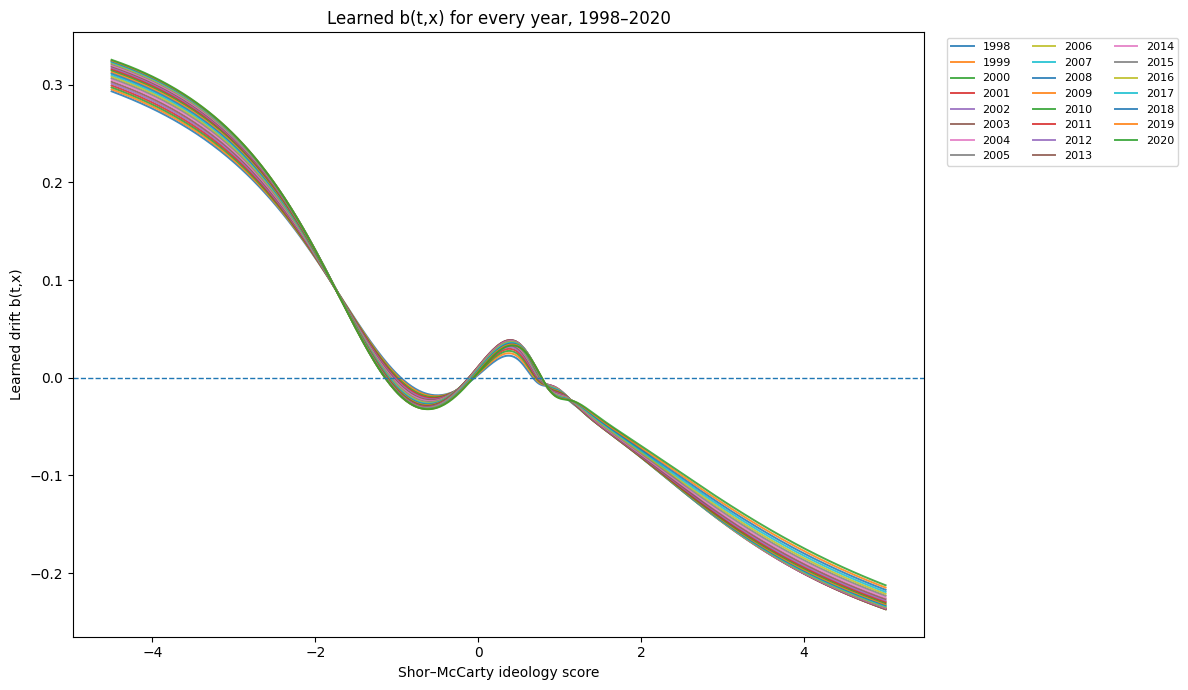

In [5]:
plt.figure(figsize=(12, 7))
for i, year in enumerate(years):
    plt.plot(
        x_grid,
        b_all[i],
        label=str(year),
        linewidth=1.4,
        alpha=0.85,
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Shor–McCarty ideology score")
plt.ylabel("Learned drift b(t,x)")
plt.title("Learned b(t,x) for every year, 1998–2020")
plt.legend(ncol=3, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


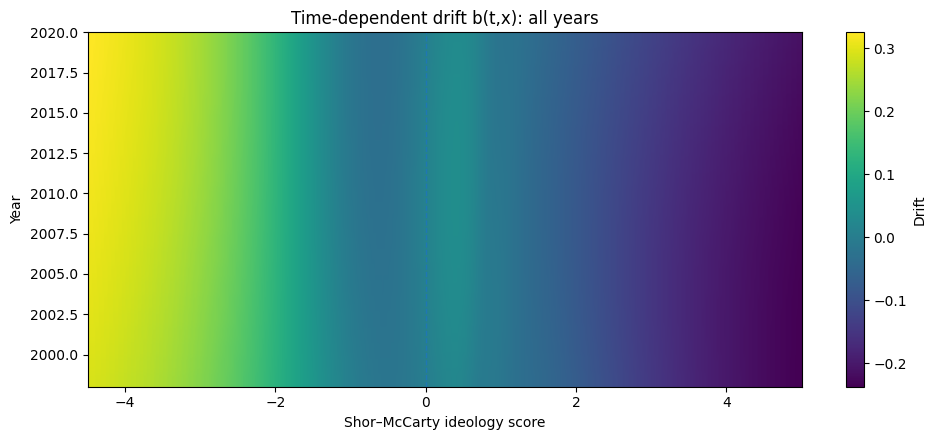

In [6]:
plt.figure(figsize=(10, 4.5))
plt.imshow(
    b_all,
    aspect="auto",
    origin="lower",
    extent=[x_grid.min(), x_grid.max(), years.min(), years.max()],
)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Shor–McCarty ideology score")
plt.ylabel("Year")
plt.title("Time-dependent drift b(t,x): all years")
plt.colorbar(label="Drift")
plt.tight_layout()
plt.show()


## 4. Selected $p$ and $b$ snapshots together

For easier interpretation, the next figure shows the learned drift only at the same representative years used in the $p(t,x)$ snapshot plot.

The two figures can be read together:

- the $p(t,x)$ plot shows **where ideological mass is located**;
- the $b(t,x)$ plot shows **the systematic direction of transport implied by the fitted Fokker–Planck dynamics**.


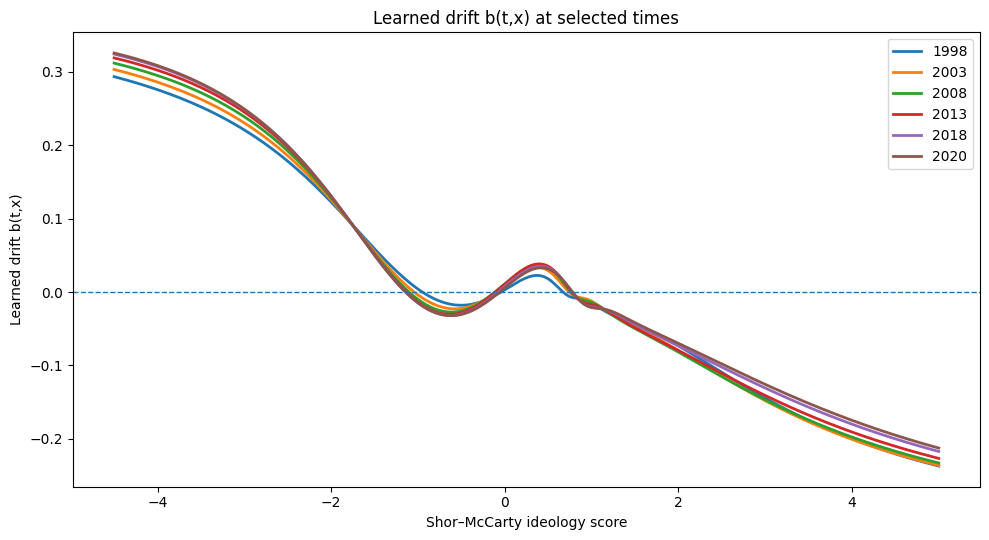

In [7]:
plt.figure(figsize=(10, 5.5))
for year in snapshot_years:
    idx = np.where(years == year)[0][0]
    plt.plot(x_grid, b_all[idx], label=str(year), linewidth=2)

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Shor–McCarty ideology score")
plt.ylabel("Learned drift b(t,x)")
plt.title("Learned drift b(t,x) at selected times")
plt.legend()
plt.tight_layout()
plt.show()


## Interpretation note

This run answers a different question from the earlier forecasting notebook.

The earlier notebook asked:

> Can dynamics estimated from earlier years predict held-out future years?

This notebook instead asks:

> If we use the entire 1998–2020 history, what does the inferred time-varying drift field $b(t,x)$ look like, and how does it correspond to the observed evolution of $p(t,x)$?

Because all years are used during training, the resulting $b(t,x)$ plots are **descriptive/inverse-dynamics estimates**, not out-of-sample forecasts.
